# Decision Tree: Drug Prescription Classifier
## Árbol de Decisión: Clasificador de Prescripción de Medicamentos

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `drugs.csv` — 200 patients × 5 features | Target: drug type (5 classes: drugA, drugB, drugC, drugX, drugY)

**Objective / Objetivo:**  
EN · Build a Decision Tree classifier to predict which drug to prescribe based on patient characteristics (age, sex, blood pressure, cholesterol, Na/K ratio). Compare GINI vs Entropy criteria across 6 depth levels (1-6), 12 models total, and select the most parsimonious model.

ES · Construir un clasificador de Árbol de Decisión para predecir qué medicamento prescribir según características del paciente. Comparar criterios GINI vs Entropía en 6 niveles de profundidad (1-6), 12 modelos en total, y seleccionar el modelo más parsimonioso.

**Key finding / Hallazgo clave:** GINI and Entropy produced identical results at all depths. Optimal model: depth=4, Accuracy=98.33%

**Techniques / Técnicas:** Decision Tree · GINI vs Entropy · Depth Tuning · Feature Importance · New Patient Prediction  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib`

---

# Importación de Librerías y Carga de Datos

In [21]:
# ============================================================
# Importación de librerías necesarias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn import preprocessing
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Carga de datos
# ============================================================

df = pd.read_csv('drugs.csv')

print('=' * 65)
print("INFORMACIÓN GENERAL DEL DATASET")
print('=' * 65)
print(f"\n⋆ Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n⋆ Información del dataset:")
print(df.info())
print(f"\n⋆ 5 filas aleatorias:")
print(df.sample(5, random_state=42))

# Distribución de las variables tipo object
print("\n⋆ Distribución de la variable Sex:")
print(df['Sex'].value_counts())
print("\n⋆ Distribución de la variable BP:")
print(df['BP'].value_counts())
print("\n⋆ Distribución de la variable Cholesterol:")
print(df['Cholesterol'].value_counts())
print("\n⋆ Distribución de la variable Drug (objetivo):")
print(df['Drug'].value_counts())

INFORMACIÓN GENERAL DEL DATASET

⋆ Dimensiones: 200 filas x 6 columnas

⋆ Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None

⋆ 5 filas aleatorias:
     Age Sex      BP Cholesterol  Na_to_K   Drug
95    36   M     LOW      NORMAL   11.424  drugX
15    16   F    HIGH      NORMAL   15.516  drugY
30    18   F  NORMAL      NORMAL    8.750  drugX
158   59   F     LOW        HIGH   10.444  drugC
128   47   M     LOW      NORMAL   33.542  drugY

⋆ Distribución de la variable Sex:
Sex
M    104
F     96
Name: count, dtype:

# Preprocesamiento de Datos: Codificación de Variables Categóricas con LabelEncoder

In [22]:
# ============================================================
# Preprocesamiento: Codificación de variables
# ============================================================
print('=' * 65)
print("CODIFICACIÓN CON LabelEncoder")
print('=' * 65)

le = preprocessing.LabelEncoder()

# Crear copia del DataFrame para no modificar el original
df_encoded = df.copy()

# --- Variable: Sex ---
le.fit(['F', 'M'])
df_encoded['Sex'] = le.transform(df['Sex'])
print("\n▸ Sex → Clases originales:", le.classes_)
print("  Mapeo: F=0, M=1")

# --- Variable: BP (Presión Arterial) ---
le.fit(['HIGH', 'LOW', 'NORMAL'])
df_encoded['BP'] = le.transform(df['BP'])
print("\n▸ BP → Clases originales:", le.classes_)
print("  Mapeo: HIGH=0, LOW=1, NORMAL=2")

# --- Variable: Cholesterol ---
le.fit(['HIGH', 'NORMAL'])
df_encoded['Cholesterol'] = le.transform(df['Cholesterol'])
print("\n▸ Cholesterol → Clases originales:", le.classes_)
print("  Mapeo: HIGH=0, NORMAL=1")

# --- Variable objetivo: Drug ---
le_drug = preprocessing.LabelEncoder()
le_drug.fit(['drugA', 'drugB', 'drugC', 'drugX', 'drugY'])
df_encoded['Drug'] = le_drug.transform(df['Drug'])
print("\n▸ Drug → Clases originales:", le_drug.classes_)
print("  Mapeo: drugA=0, drugB=1, drugC=2, drugX=3, drugY=4")

print("\n⋆ DataFrame codificado (primeras 10 filas):")
print(df_encoded.head(10))
print("\n⋆ Resumen estadístico:")
print(df_encoded.describe())

CODIFICACIÓN CON LabelEncoder

▸ Sex → Clases originales: ['F' 'M']
  Mapeo: F=0, M=1

▸ BP → Clases originales: ['HIGH' 'LOW' 'NORMAL']
  Mapeo: HIGH=0, LOW=1, NORMAL=2

▸ Cholesterol → Clases originales: ['HIGH' 'NORMAL']
  Mapeo: HIGH=0, NORMAL=1

▸ Drug → Clases originales: ['drugA' 'drugB' 'drugC' 'drugX' 'drugY']
  Mapeo: drugA=0, drugB=1, drugC=2, drugX=3, drugY=4

⋆ DataFrame codificado (primeras 10 filas):
   Age  Sex  BP  Cholesterol  Na_to_K  Drug
0   23    0   0            0   25.355     4
1   47    1   1            0   13.093     2
2   47    1   1            0   10.114     2
3   28    0   2            0    7.798     3
4   61    0   1            0   18.043     4
5   22    0   2            0    8.607     3
6   49    0   2            0   16.275     4
7   41    1   1            0   11.037     2
8   60    1   2            0   15.171     4
9   43    1   1            1   19.368     4

⋆ Resumen estadístico:
              Age         Sex          BP  Cholesterol     Na_to_K       

# División del Dataset y Preparación de Características

In [25]:
# ============================================================
# Separación de características (X) y objetivo (y)
# ============================================================
feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
X = df_encoded[feature_cols]
y = df_encoded['Drug']

# División 70% entrenamiento / 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42,
    stratify=y  # Mantiene proporciones de clases
)

print('=' * 65)
print("DIVISIÓN DEL DATASET")
print('=' * 65)
print(f"\n⋆ Total de muestras: {len(df)}")
print(f"⋆ Muestras de entrenamiento: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"⋆ Muestras de prueba: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"\n⋆ Características usadas: {feature_cols}")
print(f"⋆ Variable objetivo: Drug")

DIVISIÓN DEL DATASET

⋆ Total de muestras: 200
⋆ Muestras de entrenamiento: 140 (70.0%)
⋆ Muestras de prueba: 60 (30.0%)

⋆ Características usadas: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
⋆ Variable objetivo: Drug


# Entrenamiento con Criterio GINI con Múltiples Profundidades

In [63]:
# ============================================================
# Modelos con criterio GINI
# ============================================================
print('=' * 65)
print("MODELOS CON CRITERIO: GINI IMPURITY")
print('=' * 65)

profundidades = [2, 3, 4, 5, 6, None]
resultados_gini = {}

for depth in profundidades:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados_gini[depth] = {'modelo': clf, 'accuracy': acc, 'predicciones': y_pred}
    
    label = f"profundidad={depth}" if depth else "profundidad=Sin límite"
    print(f"\n{'─'*55}")
    print(f"  GINI | {label.upper()} | Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'─'*55}")
    print(classification_report(y_test, y_pred, target_names=le_drug.classes_))

MODELOS CON CRITERIO: GINI IMPURITY

───────────────────────────────────────────────────────
  GINI | PROFUNDIDAD=2 | Accuracy: 0.8333 (83.33%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       0.58      1.00      0.74         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      1.00      0.86        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.47      0.60      0.52        60
weighted avg       0.72      0.83      0.77        60


───────────────────────────────────────────────────────
  GINI | PROFUNDIDAD=3 | Accuracy: 0.8667 (86.67%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      0.80     

# Entrenamiento con Criterio ENTROPÍA con Múltiples Profundidades

In [64]:
# ============================================================
# Modelos con criterio ENTROPÍA
# ============================================================
print('=' * 65)
print("MODELOS CON CRITERIO: ENTROPÍA (Information Gain)")
print('=' * 65)

resultados_entropia = {}

for depth in profundidades:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados_entropia[depth] = {'modelo': clf, 'accuracy': acc, 'predicciones': y_pred}
    
    label = f"profundidad={depth}" if depth else "profundidad=Sin límite"
    print(f"\n{'─'*55}")
    print(f"  ENTROPIA | {label.upper()} | Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'─'*55}")
    print(classification_report(y_test, y_pred, target_names=le_drug.classes_))

MODELOS CON CRITERIO: ENTROPÍA (Information Gain)

───────────────────────────────────────────────────────
  ENTROPIA | PROFUNDIDAD=2 | Accuracy: 0.8333 (83.33%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       0.58      1.00      0.74         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      1.00      0.86        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.47      0.60      0.52        60
weighted avg       0.72      0.83      0.77        60


───────────────────────────────────────────────────────
  ENTROPIA | PROFUNDIDAD=3 | Accuracy: 0.8667 (86.67%)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB    

# Tabla Comparativa de Resultados

In [34]:
# ============================================================
# Tabla comparativa
# ============================================================
print('=' * 65)
print("TABLA COMPARATIVA DE RESULTADOS")
print('=' * 65)
print(f"\n{'Criterio':<12} {'Profundidad':<14} {'Accuracy':<12} {'Evaluación'}")
print('⎯' * 65)

for depth in profundidades:
    d_label = str(depth) if depth else "Sin límite"
    acc_g = resultados_gini[depth]['accuracy']
    acc_e = resultados_entropia[depth]['accuracy']
    
    eval_g = "☆ Excelente" if acc_g >= 0.95 else ("✔ Bueno" if acc_g >= 0.85 else "△ Regular")
    eval_e = "☆ Excelente" if acc_e >= 0.95 else ("✔ Bueno" if acc_e >= 0.85 else "△ Regular")
    
    print(f"{'GINI':<12} {d_label:<14} {acc_g:<12.4f} {eval_g}")
    print(f"{'ENTROPÍA':<12} {d_label:<14} {acc_e:<12.4f} {eval_e}")
    print('⎯' * 65)

TABLA COMPARATIVA DE RESULTADOS

Criterio     Profundidad    Accuracy     Evaluación
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
GINI         2              0.8333       △ Regular
ENTROPÍA     2              0.8333       △ Regular
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
GINI         3              0.8667       ✔ Bueno
ENTROPÍA     3              0.8667       ✔ Bueno
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
GINI         4              0.9833       ☆ Excelente
ENTROPÍA     4              0.9833       ☆ Excelente
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
GINI         5              0.9833       ☆ Excelente
ENTROPÍA     5              0.9833       ☆ Excelente
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
GINI         6              0.9833       ☆ Excelente
ENTROPÍA     6              0.9833       ☆ Excelente
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
G

# Visualización de Comparación de Accuracy

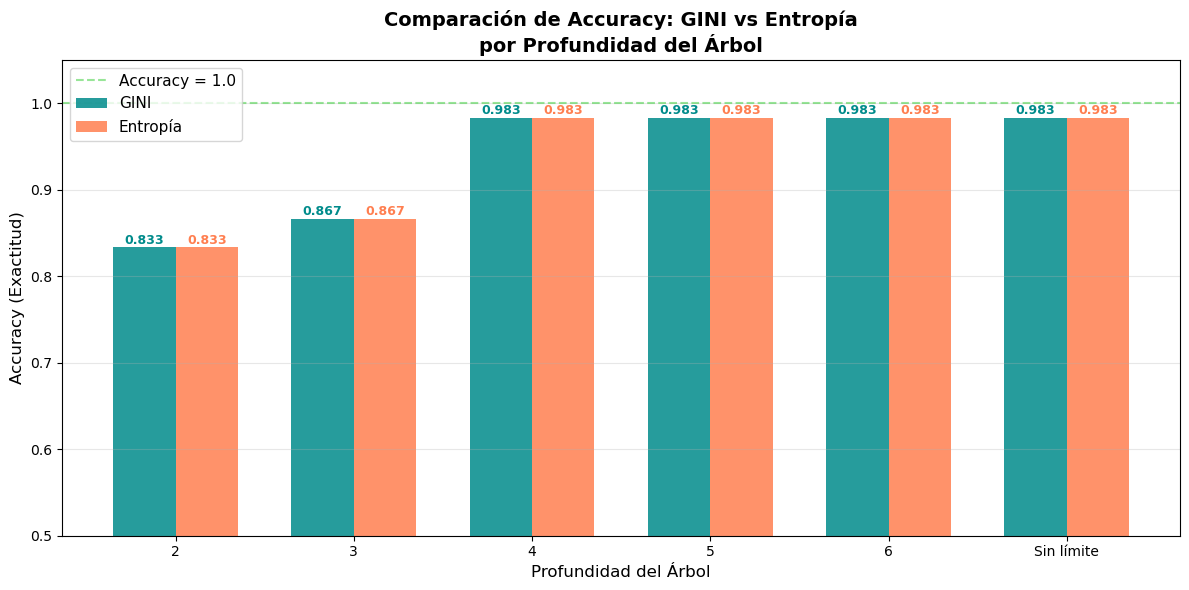

In [67]:
# ============================================================
# Gráfico comparativo de accuracy
# ============================================================
labels_depth = ['2', '3', '4', '5', '6', 'Sin límite']
acc_gini_vals = [resultados_gini[d]['accuracy'] for d in profundidades]
acc_entropia_vals = [resultados_entropia[d]['accuracy'] for d in profundidades]

x = np.arange(len(labels_depth))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, acc_gini_vals, width, label='GINI', color='darkcyan', alpha=0.85)
bars2 = ax.bar(x + width/2, acc_entropia_vals, width, label='Entropía', color='coral', alpha=0.85)

# Etiquetas de valor sobre cada barra
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 0.6), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='darkcyan', fontweight='bold')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 0.6), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='coral', fontweight='bold')

ax.set_xlabel('Profundidad del Árbol', fontsize=12)
ax.set_ylabel('Accuracy (Exactitud)', fontsize=12)
ax.set_title('Comparación de Accuracy: GINI vs Entropía\npor Profundidad del Árbol', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_depth)
ax.set_ylim(0.5, 1.05)
ax.axhline(y=1.0, color='limegreen', linestyle='--', alpha=0.5, label='Accuracy = 1.0')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('tree_comparacion_accuracy.png', dpi=150)
plt.show()

# Mejor Modelo: Reporte Detallado y Matriz de Confusión

MEJOR MODELO IDENTIFICADO

  ✔ Criterio: GINI
  ✔ Profundidad: 4
  ✔ Accuracy: 0.9833 (98.33%)

⋆ Reporte de Clasificación Completo: 
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      0.80      0.89         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



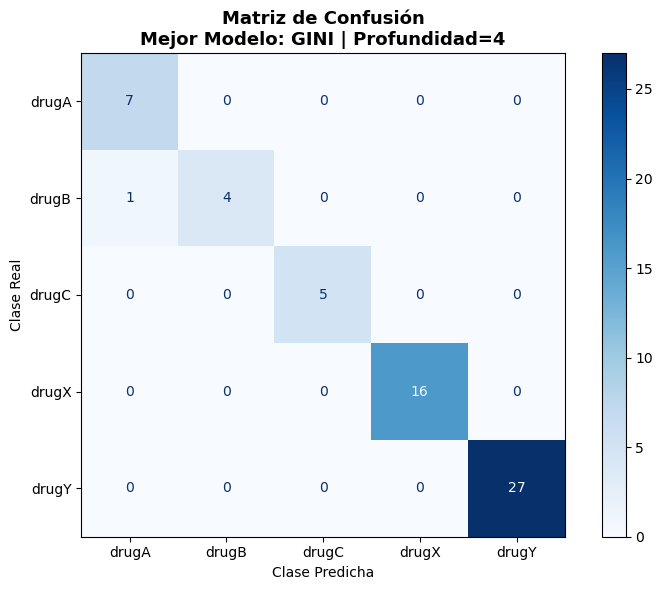

In [72]:
# ============================================================
# Selección y análisis del mejor modelo
# ============================================================

# Seleccionar el modelo con mayor accuracy
mejor_depth_g = max(resultados_gini, key=lambda d: resultados_gini[d]['accuracy'])
mejor_depth_e = max(resultados_entropia, key=lambda d: resultados_entropia[d]['accuracy'])
mejor_acc_g = resultados_gini[mejor_depth_g]['accuracy']
mejor_acc_e = resultados_entropia[mejor_depth_e]['accuracy']

if mejor_acc_g >= mejor_acc_e: # Si GINI y ENTROPÍA empatan elegir GINI como mejor modelo (Gini suele ser ligeramente más rápido computacionalmente)
    mejor_criterio  = 'GINI'
    mejor_depth     = mejor_depth_g
    mejor_acc       = mejor_acc_g
    mejor_modelo    = resultados_gini[mejor_depth_g]['modelo']
    mejores_preds   = resultados_gini[mejor_depth_g]['predicciones']
else:
    mejor_criterio  = 'ENTROPÍA'
    mejor_depth     = mejor_depth_e
    mejor_acc       = mejor_acc_e
    mejor_modelo    = resultados_entropia[mejor_depth_e]['modelo']
    mejores_preds   = resultados_entropia[mejor_depth_e]['predicciones']

print('=' * 65)
print("MEJOR MODELO IDENTIFICADO")
print('=' * 65)
print(f"\n  ✔ Criterio: {mejor_criterio}")
print(f"  ✔ Profundidad: {mejor_depth}")
print(f"  ✔ Accuracy: {mejor_acc:.4f} ({mejor_acc*100:.2f}%)")

print("\n⋆ Reporte de Clasificación Completo: ")
print(classification_report(y_test, mejores_preds,target_names=le_drug.classes_))

# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, mejores_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_drug.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Matriz de Confusión\nMejor Modelo: {mejor_criterio} | Profundidad={mejor_depth}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Clase Real', fontsize=10)
ax.set_xlabel('Clase Predicha', fontsize=10)

plt.tight_layout()
plt.savefig('tree_matriz_confusion.png', dpi=150)
plt.show()

# Visualización del Árbol de Decisión

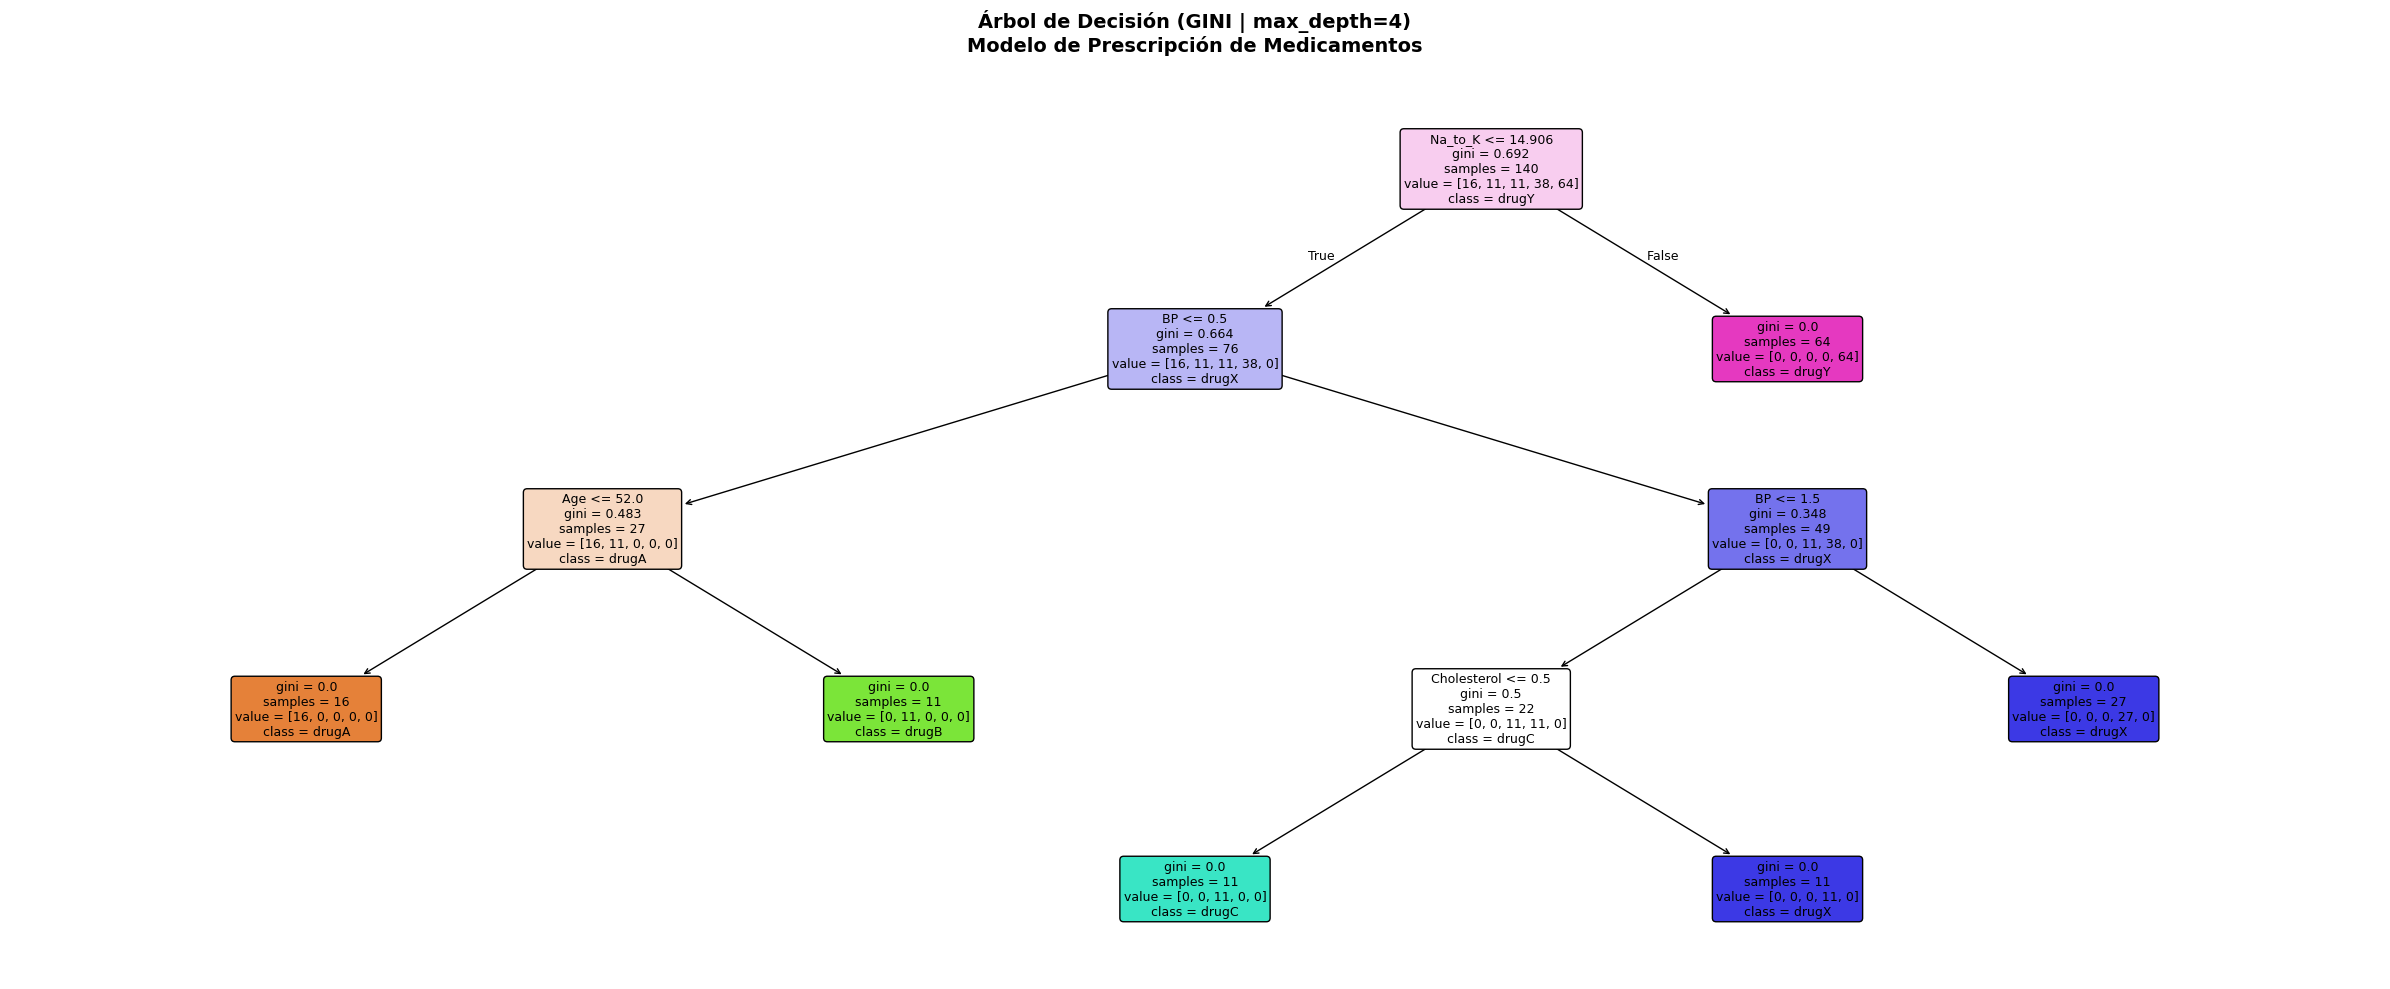


REGLAS DEL ÁRBOL (Formato Texto)
|--- Na_to_K <= 14.91
|   |--- BP <= 0.50
|   |   |--- Age <= 52.00
|   |   |   |--- class: 0
|   |   |--- Age >  52.00
|   |   |   |--- class: 1
|   |--- BP >  0.50
|   |   |--- BP <= 1.50
|   |   |   |--- Cholesterol <= 0.50
|   |   |   |   |--- class: 2
|   |   |   |--- Cholesterol >  0.50
|   |   |   |   |--- class: 3
|   |   |--- BP >  1.50
|   |   |   |--- class: 3
|--- Na_to_K >  14.91
|   |--- class: 4



In [74]:
# ============================================================
# Visualización gráfica del árbol óptimo: GINI profundidad 4
# ============================================================

clf_visual = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    clf_visual,
    feature_names=feature_cols,
    class_names=le_drug.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Árbol de Decisión (GINI | max_depth=4)\nModelo de Prescripción de Medicamentos',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('tree_arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Reglas en texto ---
print('\n' + '=' * 65)
print("REGLAS DEL ÁRBOL (Formato Texto)")
print('=' * 65)
rules = export_text(clf_visual, feature_names=feature_cols)
print(rules)

# Importancia de Variables

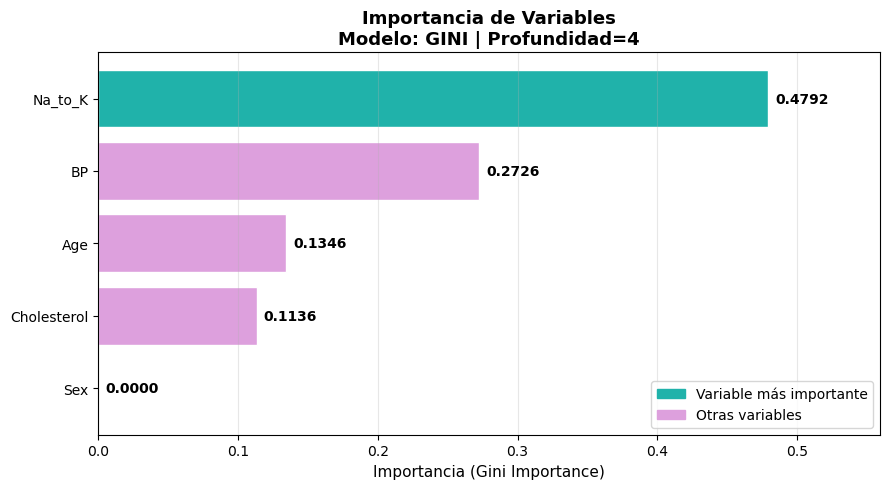

In [79]:
# ============================================================
# Importancia de características
# ============================================================
importances = pd.Series(mejor_modelo.feature_importances_, index=feature_cols).sort_values(ascending=True)

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['lightseagreen' if v == importances.max() else 'plum' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
# Etiquetas
ax.set_xlabel('Importancia (Gini Importance)', fontsize=11)
ax.set_title(f'Importancia de Variables\nModelo: {mejor_criterio} | Profundidad={mejor_depth}',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() + 0.08)
ax.grid(axis='x', alpha=0.3)
max_patch = mpatches.Patch(color='lightseagreen', label='Variable más importante')
other_patch = mpatches.Patch(color='plum', label='Otras variables')
ax.legend(handles=[max_patch, other_patch], loc='lower right')

plt.tight_layout()
plt.savefig('tree_importancia_variables.png', dpi=150)
plt.show()

# Predicción para el Nuevo Paciente

In [83]:
# ============================================================
# PREDICCIÓN PARA EL NUEVO PACIENTE
# Age=50, Sex=F, BP=HIGH, Cholesterol=NORMAL, Na_to_K=15.302
# ============================================================
print('\n' + '=' * 65)
print("PREDICCIÓN PARA NUEVO PACIENTE")
print('=' * 65)

# Codificar manualmente con el mismo criterio que el entrenamiento
# Sex: F=0, M=1
# BP: HIGH=0, LOW=1, NORMAL=2
# Cholesterol: HIGH=0, NORMAL=1
nuevo_paciente = pd.DataFrame({
    'Age':         [50],
    'Sex':         [0],     # F → 0
    'BP':          [0],     # HIGH → 0
    'Cholesterol': [1],     # NORMAL → 1
    'Na_to_K':     [15.302]
})

print("\n⋆ Datos originales del paciente:")
print(f"  Age         : 50")
print(f"  Sex         : F (codificado → 0)")
print(f"  BP          : HIGH (codificado → 0)")
print(f"  Cholesterol : NORMAL (codificado → 1)")
print(f"  Na_to_K     : 15.302")

prediccion_num  = mejor_modelo.predict(nuevo_paciente)[0]
prediccion_drug = le_drug.inverse_transform([prediccion_num])[0]
probabilidades  = mejor_modelo.predict_proba(nuevo_paciente)[0]

print(f"\n{'─'*55}")
print(f"  ➤ MEDICAMENTO RECOMENDADO: {prediccion_drug}")
print(f"{'─'*55}")
print(f"\n⋆ Probabilidades por clase:")
for clase, prob in zip(le_drug.classes_, probabilidades):
    print(f"  {clase:4s}: {prob:.2f} ({prob*100:2.1f}%)")


PREDICCIÓN PARA NUEVO PACIENTE

⋆ Datos originales del paciente:
  Age         : 50
  Sex         : F (codificado → 0)
  BP          : HIGH (codificado → 0)
  Cholesterol : NORMAL (codificado → 1)
  Na_to_K     : 15.302

───────────────────────────────────────────────────────
  ➤ MEDICAMENTO RECOMENDADO: drugY
───────────────────────────────────────────────────────

⋆ Probabilidades por clase:
  drugA: 0.00 (0.0%)
  drugB: 0.00 (0.0%)
  drugC: 0.00 (0.0%)
  drugX: 0.00 (0.0%)
  drugY: 1.00 (100.0%)


# Análisis y Conclusiones

### Preprocesamiento
Las variables categóricas `Sex`, `BP` y `Cholesterol` fueron codificadas  numéricamente con `LabelEncoder`. 
El dataset contiene **200 registros** sin valores nulos, divididos en 70% entrenamiento (140) y 30% prueba (60), 
manteniendo proporciones de clase con `stratify`.

### Comparación de modelos
Se entrenaron **12 modelos** en total (6 profundidades × 2 criterios). 
Ambos criterios (GINI y Entropía) produjeron **resultados idénticos** en todas las profundidades evaluadas.

El salto más significativo ocurre entre profundidad 3 y 4, donde el modelo gana capacidad para distinguir `drugC` y `drugX` correctamente.

### Mejor modelo: GINI | profundidad = 4
Se selecciona **GINI con profundidad 4** por ser el modelo más simple que alcanza el accuracy máximo (98.33%), 
favoreciendo la interpretabilidad y reduciendo el riesgo de sobreajuste frente a profundidades mayores.

- **drugA** → F1 = 0.93 | 1 error (un paciente drugB clasificado como drugA)
- **drugB** → F1 = 0.89 | 1 error (recall 0.80, el caso más débil del modelo)
- **drugC, drugX, drugY** → F1 = 1.00 | Sin errores

### Variable más importante
`Na_to_K` (0.4792) es el predictor dominante, seguido de `BP` (0.2726), `Age` (0.1346) y `Cholesterol` (0.1136).
El sexo del paciente no aporta información discriminante (importancia = 0.0).

### Reglas del árbol
El árbol toma decisiones en este orden:
1. Si `Na_to_K > 14.91` → **drugY** (decisión inmediata, 64 pacientes)
2. Si `Na_to_K ≤ 14.91` y `BP = HIGH` y `Age ≤ 52` → **drugA**
3. Si `Na_to_K ≤ 14.91` y `BP = HIGH` y `Age > 52` → **drugB**
4. Si `Na_to_K ≤ 14.91` y `BP = LOW` y `Cholesterol = HIGH` → **drugC**
5. Resto (BP = NORMAL o LOW + Colesterol NORMAL) → **drugX**

### Predicción nuevo paciente
Para la paciente (Age=50, Sex=F, BP=HIGH, Cholesterol=NORMAL, Na_to_K=15.302):
- Na_to_K = 15.302 > 14.91 → rama derecha → **drugY** con 100% de confianza.